In [1]:
import dasly
from dasly.fitting.hyperbola_fitter import (
    fit_multiple_hyperbolas_least_squares,
    derive_hyperbola_metrics,
)
from dasly.execution.box_saver import build_box_df
from dasly.detection.tm import create_v_template
from dasly.loader.fsearcher import parse_file_path


# Parameters


In [2]:
file_paths = [
    '../data/svalbard/20220822/dphi/122539.hdf5',
    '../data/svalbard/20220822/dphi/122549.hdf5',
    '../data/svalbard/20220822/dphi/122559.hdf5',
]

s_start, s_end = 5_000, 115_000  # Start and end channel indices
f_min, f_max = 15, 25  # Hz
v_min, v_max = 1_484, 1_4844  # m/s
rms_window_size = 0.5  # Window size for RMS calculation in seconds
new_size = (640, 640)  # New size for resizing (width, height)
gray_by_channel = True  # Apply grayscale transformation by channel
dx = 1.0213001907746815  # Distance between channels in meters
template_target_velocity = 1_750  # Target velocity for template matching
template_t = 4  # Template duration in seconds
template_t_width = 0.5  # Template width in seconds
binary_threshold = 0.2  # Threshold for binary transformation
dbscan_points_eps = 2.3  # DBSCAN epsilon in seconds
dbscan_points_min_samples = 15  # Min samples for DBSCAN
dbscan_points_target_velocity = 1_750  # m/s
hyperbolas_num_points = 10  # Number of binary transformed points preserved
hyperbolas_by_channel = True  # Binary transformed points by channel


# Detection


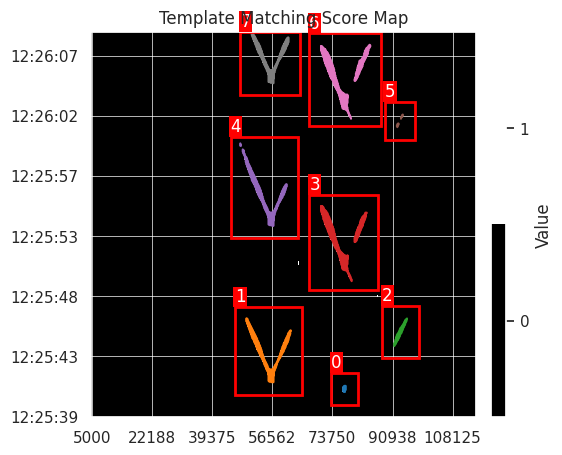

In [3]:
das_rms = (
    dasly.DASArray()
    .load(file_paths=file_paths, s_start=s_start, s_end=s_end)
    .fk_filter_real(f_min=f_min, f_max=f_max, v_min=v_min, v_max=v_max)
    .rms(window_size_second=rms_window_size)
)

das_grayscale = (
    das_rms
    .resize_cv2(new_size=new_size)
    .grayscale_transform(by_column=False)
)

# Precompute the velocity template
v_template = create_v_template(
    v=template_target_velocity,
    dt=das_grayscale.meta.dt,
    dx=das_grayscale.meta.ds * das_grayscale.meta.dx,
    t=template_t,
    x=None,
    t_width=template_t_width,
    x_width=None
)

das = (
    das_grayscale
    .template_matching(template=v_template)
    .clip_negative_values()
    .binary_transform(threshold=binary_threshold)
    .dbscan_points(
        eps=dbscan_points_eps / (len(file_paths) * 10 / new_size[1]),
        min_samples=dbscan_points_min_samples,
        target_velocity=dbscan_points_target_velocity
    )
    .adjust_template_boxes(template_shape=v_template.shape)
)

fig, ax = das.plot(
    figsize=(5, 5),
    colorbar=True,
    title='Template Matching Score Map',
    xlabel='',
    ylabel='',
    show=True,
    clusters=das.meta.cluster_labels,
    clusters_legend=False,
)

dasly.add_boxes(fig, das.meta.boxesn, num_boxes=True)


# Detection Boxes Information


In [4]:
hyperbolas = fit_multiple_hyperbolas_least_squares(
    array=das_rms,
    boxesn=das.meta.boxesn,
    num_points=hyperbolas_num_points,
    by_channel=hyperbolas_by_channel
)

hyper_metrics = derive_hyperbola_metrics(
    hyperbolas=hyperbolas,
    ds=das_rms.meta.ds,
    dx=das_rms.meta.dx
)

exp_path, yyyymmdd, hhmmss, hhmmss_hdf5 = parse_file_path(file_paths[0])
chunk = f'{yyyymmdd}T{hhmmss}'
additional = {
    'source_distance': hyper_metrics['source_distance'],
    'hyper_rmse_norm': hyper_metrics['hyper_rmse_norm'],
    'hyper_mae_norm': hyper_metrics['hyper_mae_norm'],
    'dbscan_size': das.meta.cluster_sizes
}

boxes_df = build_box_df(
    boxesp=das.meta.boxesp,
    boxesn=das.meta.boxesn,
    chunk=chunk,
    chunk_size=len(file_paths),
    additional=additional
)

boxes_df


,s1,t1,s2,t2,x1n,y1n,x2n,y2n,chunk,chunk_size,source_distance,hyper_rmse_norm,hyper_mae_norm,dbscan_size
0,73256.463623,2022-08-22 12:25:39.900933743+00:00,80892.950439,2022-08-22 12:25:42.404827833+00:00,0.621484,0.030078,0.691016,0.113672,20220822T122539,3,221310.230696,0.297252,0.242686,48
1,45799.432373,2022-08-22 12:25:40.696563721+00:00,64933.551025,2022-08-22 12:25:47.506219387+00:00,0.371484,0.056641,0.545703,0.283984,20220822T122539,3,1404.140901,0.095333,0.045445,970
2,87843.011475,2022-08-22 12:25:43.551470995+00:00,98389.943604,2022-08-22 12:25:47.597950935+00:00,0.754297,0.151953,0.850328,0.287047,20220822T122539,3,6606.400006,0.184460,0.115292,205
3,67078.631592,2022-08-22 12:25:48.858790398+00:00,86555.963135,2022-08-22 12:25:56.258148193+00:00,0.565234,0.329141,0.742578,0.576172,20220822T122539,3,3285.577286,0.072903,0.043786,1341
4,44598.187256,2022-08-22 12:25:52.911822557+00:00,63903.912354,2022-08-22 12:26:00.746436834+00:00,0.360547,0.464453,0.536328,0.726016,20220822T122539,3,974.636537,0.083386,0.042310,1011
5,88575.770996,2022-08-22 12:26:00.506343842+00:00,97195.562744,2022-08-22 12:26:03.499784231+00:00,0.760969,0.718000,0.839453,0.817937,20220822T122539,3,0.016549,0.239654,0.182294,28
6,67078.631592,2022-08-22 12:26:01.623033762+00:00,87563.292969,2022-08-22 12:26:08.801019192+00:00,0.565234,0.755281,0.751750,0.994922,20220822T122539,3,2635.475876,0.104781,0.054567,1414
7,47343.890381,2022-08-22 12:26:04.003839016+00:00,64540.572266,2022-08-22 12:26:08.953125+00:00,0.385547,0.834766,0.542125,1.000000,20220822T122539,3,1991.237739,0.074944,0.028892,830
